In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
import logging

In [2]:
a = np.array([[1,2,3],[2,3,4]])

In [3]:
np.mean(a, axis=0)

array([1.5, 2.5, 3.5])

In [4]:
b = np.ones((5,100))

In [5]:
np.mean(b, axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
# Trying to see if class b changes into class a affect class c
class parent:
    def __init__(self):
        self.val = 1

class child_a(parent):
    def __init__(self, par: parent):
        super().__init__()
        self.par = par
    
    def setVal(self, val):
        self.par.val = val

class child_b(parent):
    def __init__(self, par: parent):
        super().__init__()
        self.par = par
    
    def printVal(self):
        print(self.par.val)
ob = parent()
ob1 = child_a(ob)
ob2 = child_b(ob)

ob1.setVal(2)
ob2.printVal()

2


In [41]:
a = np.array([np.sin(np.linspace(0, 10, 100)), np.cos(np.linspace(0, 10, 100))]).T
b = np.interp(np.linspace(0, len(a)-1, 200), np.arange(len(a)), a[:,0])

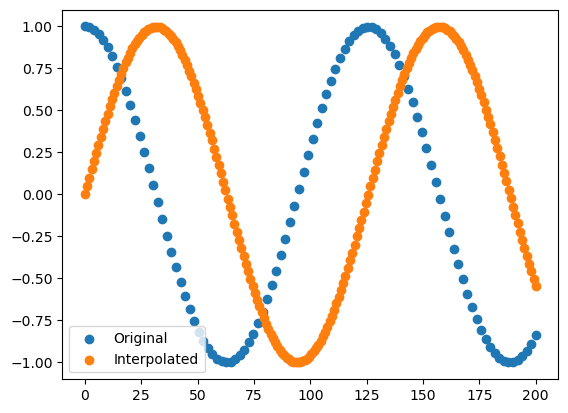

<Figure size 2000x1000 with 0 Axes>

In [42]:
plt.scatter(np.linspace(0, 200, len(a[:, 1])), a[:, 1], label='Original')
plt.scatter(np.linspace(0, 200, len(b)), b, label='Interpolated')
plt.legend()
plt.figure(figsize=(20,10))
plt.show()

In [49]:
c = [[1,2,3],[2,3,4]]

In [51]:
c[:][1]

[2, 3, 4]

In [55]:
d = np.array([a[i][1] for i in range(5)])
d

array([1.        , 0.99490282, 0.97966323, 0.95443659, 0.91948007])

In [ ]:
class Logger():

    def __init__(self):
        self.logger = logging.getLogger("TBEController")
        self._init_time = time.perf_counter()
        self.logger.handlers.clear()    # prevent duplicate handlers on re-init
        self.setFormat()

    def _get_timestamp(self):
        elapsed_time = time.perf_counter() - self._init_time
        minutes = int(elapsed_time // 60)
        seconds = int(elapsed_time % 60)
        milliseconds = int((elapsed_time - int(elapsed_time)) * 1000)
        return f"{minutes:02d}:{seconds:02d}.{milliseconds:03d}"

    def setFormat(self):

        # Custom formatter that uses our elapsed time
        logger_ref = self  # capture reference for the inner class

        class ElapsedFormatter(logging.Formatter):
            def format(self, record):
                timestamp = logger_ref._get_timestamp()
                level = record.levelname.ljust(4)
                name = record.name
                msg = record.getMessage()
                return f"[{level}][{timestamp}][{name}]: {msg}"

        console = logging.StreamHandler()
        console.setLevel(logging.INFO)
        console.setFormatter(ElapsedFormatter())
        self.logger.addHandler(console)
        self.logger.setLevel(logging.DEBUG)

In [19]:
TBElog = Logger()

In [27]:
TBElog.logger.info("This is a warning message.")

[INFO ][02:18.899][TBEController]: This is a warning message.
